In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [2]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC, GBPermanents
from circuits import CPCircuit
from qiskit_ibm_runtime.fake_provider import FakeTorino, FakeQuebec

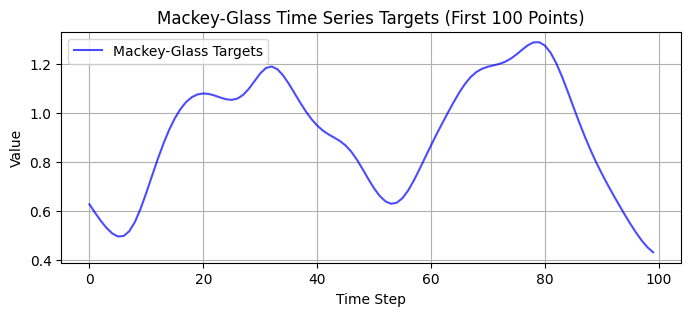

In [3]:
window_size = 20
n_samples = 10000
# X, Y = DataHandler().load_dataset('narma', n_samples = 1000, window_size=4, plot=True)
X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples, tau = 17, window_size=window_size,prediction_horizon=20, plot=True)

In [4]:
tr = 0.75
train_size = int(n_samples*tr)  # Training set size
# Split into training and testing sets
X_train_, X_test_ = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_)
X_test = scaler.transform(X_test_) 

In [6]:
itr = 5
a= -1.4746251231135765
b = 1.47
vals = np.linspace(a,b,itr)
dim = len(X_train[0])

In [7]:
backend = FakeQuebec()

In [12]:
%%time 
CP_params = None #[vals[2], np.pi/7, -np.pi/3, 7*np.pi/7,np.pi/9, -np.pi/7]
cprc = CPRC(dim=dim, execution_mode='fake_simulation', backend=backend, CP_params=CP_params, kernel = True) #simulation
esn = ESNetwork(
    reservoir=cprc, 
    dim=dim, 
    regularization=1e-6, 
    alpha=0.8, 
    show_progress=True, 
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.6, 
    cpk=True)
esn.fit(X_train, y_train)

Training Progress: 100%|██████████| 7500/7500 [34:54:01<00:00, 16.75s/ sample]   


CPU times: user 9d 1h 29min 59s, sys: 1h 59min 50s, total: 9d 3h 29min 50s
Wall time: 1d 10h 54min 2s


In [13]:
predictions = esn.predict(X_test)
rmse = mean_squared_error(y_test, predictions)

Prediction Progress: 100%|██████████| 2461/2461 [12:06:40<00:00, 17.72s/ sample]  


In [14]:
rmse

0.05489410295449761

In [15]:
predictions

array([0.86477427, 0.75634858, 0.8132245 , ..., 0.95271343, 0.64452025,
       0.68101328], shape=(2461,))

In [16]:
import pandas as pd
data_out = {"y_test": y_test, "y_pred": predictions}
df_out = pd.DataFrame(data_out)
df_out.to_csv("noisy_predictions_out.csv", index=False)

In [46]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # ── Font ──────────────────────────────────────────────────
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          12,          # base size for tick labels
    "axes.titlesize":     14,          # subplot title
    "axes.labelsize":     13,          # x/y axis labels
    "legend.fontsize":    11,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,

    # ── Line thickness ────────────────────────────────────────
    "lines.linewidth":    2.5,         # matches the chart line width
    "lines.markersize":   8,           # matches marker size

    # ── Axes ──────────────────────────────────────────────────
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,       # clean look — no top/right border
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.6,

    # ── Ticks ─────────────────────────────────────────────────
    "xtick.major.width":  1.2,
    "ytick.major.width":  1.2,
    "xtick.major.size":   5,
    "ytick.major.size":   5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",

    # ── Figure / output ───────────────────────────────────────
    "figure.dpi":         150,         # screen preview
    "savefig.dpi":        300,         # print/paper quality
    "savefig.bbox":       "tight",
    "savefig.format":     "pdf",       # vector — best for papers
})

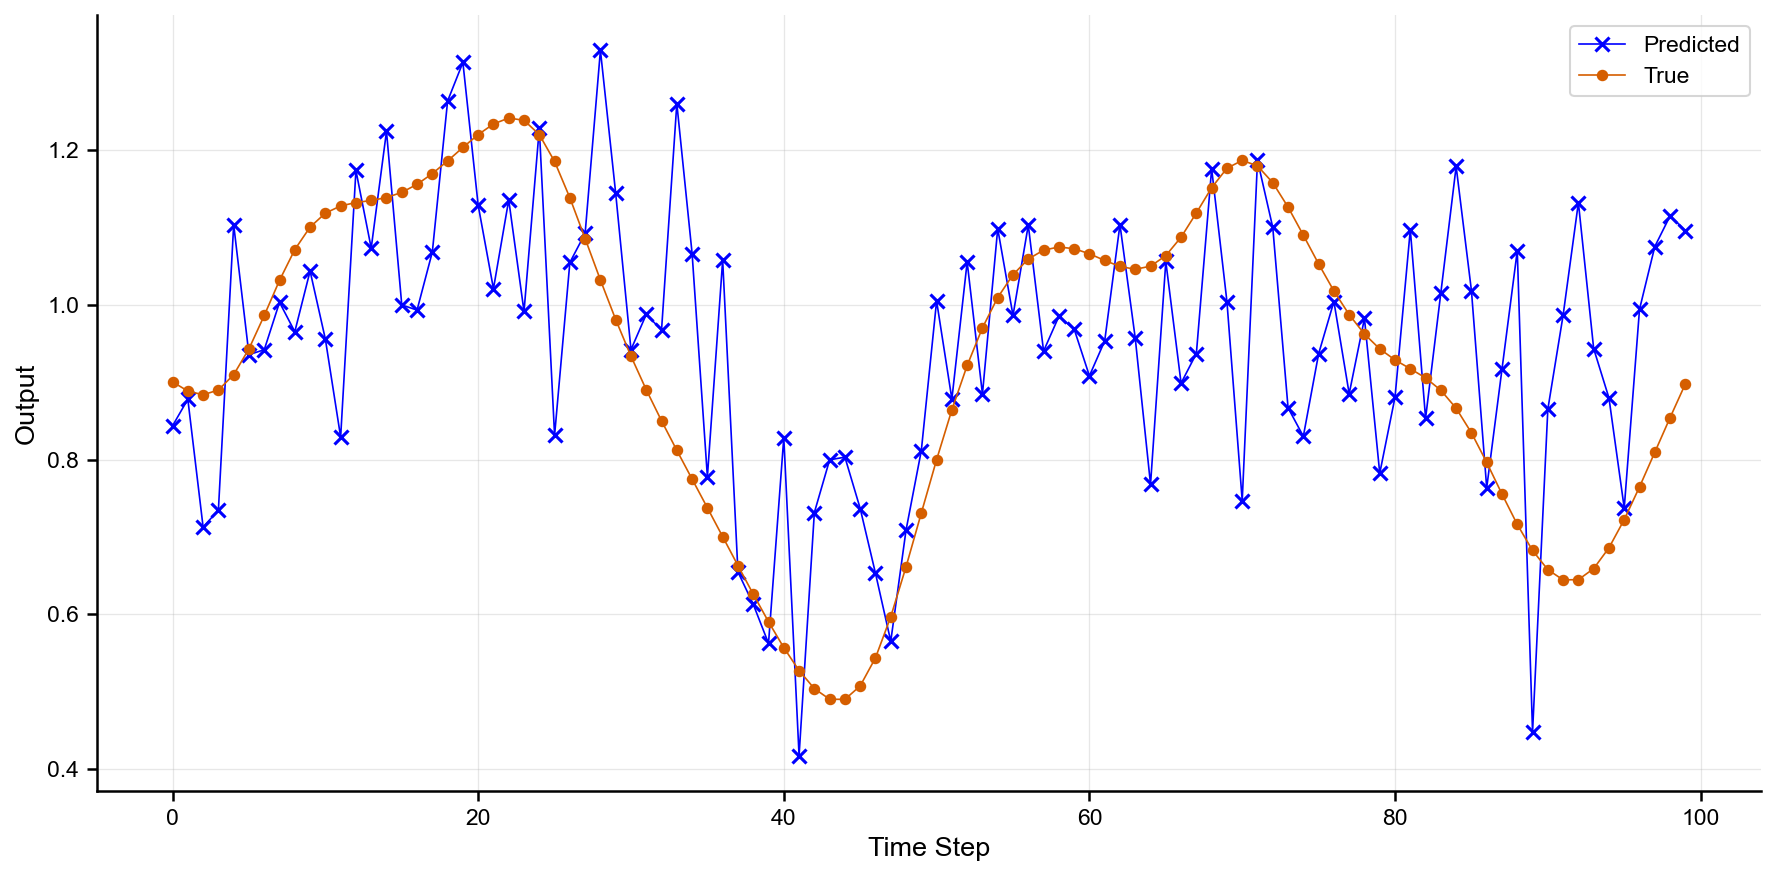

In [54]:
a=100
b=200
param_values = range(b-a) #[i for i in range(len(predictions))]
plt.figure(figsize=(12, 6))
# plt.plot(param_values, predictions[a:b], marker='x', markersize=5, color="blue", linewidth =1.5, linestyle='-', label="Predicted")
# plt.plot(param_values, y_test[a:b], marker='o', markersize=5, color="orange", linestyle='-', linewidth =1.5, label="True")

plt.plot(param_values, predictions[a:b], marker='x', markersize=7, markeredgewidth=1.5, linewidth=0.8, color="blue", linestyle='-', label="Predicted")
plt.plot(param_values, y_test[a:b], marker='o', markersize=4, markeredgewidth=1.5, markerfacecolor='#D55E00', linewidth=0.8, color="#D55E00", linestyle='-', label="True")


plt.xlabel("Time Step")
plt.ylabel("Output")
# plt.title("Performance of Quantum Reservoir vs Parameter Sweep")
plt.legend()
plt.grid(True)
plt.savefig("figures/performance_tau_17_noisy.pdf")
plt.savefig("figures/performance_tau_17_noisy.png", dpi=300)
plt.tight_layout()
plt.show()

In [12]:
rmse

0.05592390374365359

In [9]:
rmse

0.029354002183251814

In [53]:
rmse

np.float64(8.133873358740709e-07)

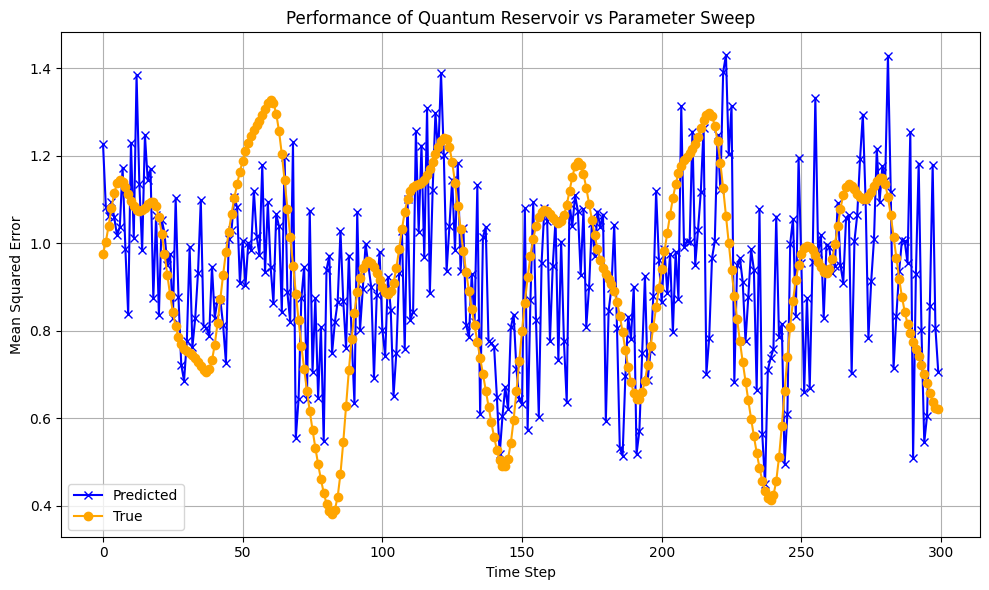

In [13]:
a=0
b=300
param_values = range(b) #[i for i in range(len(predictions))]
plt.figure(figsize=(10, 6))
plt.plot(param_values, predictions[a:b], marker='x', color="blue", linestyle='-', label="Predicted")
plt.plot(param_values, y_test[a:b], marker='o', color="orange", linestyle='-', label="True")
plt.xlabel("Time Step")
plt.ylabel("Mean Squared Error")
plt.title("Performance of Quantum Reservoir vs Parameter Sweep")
plt.legend()
plt.grid(True)
# plt.savefig("figures/performance_tau_17_noisy.pdf")
# plt.savefig("figures/performance_tau_17_noisy.png", dpi=300)
plt.tight_layout()
plt.show()